In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Device: {device}")

Device: cuda


In [3]:
BATCH_SIZE = 8

LEARNING_RATE = 5e-5

L2_LAMBDA = 1e-5

DROPOUT_RATE = 0.5

NUM_EPOCHS = 150

EARLY_STOPPING_PATIENCE = 15

POS_WEIGHT = 2.57

In [4]:
SEED = 42

torch.manual_seed(SEED)

np.random.seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)

In [5]:
PROJECT_ROOT = Path("../")

TRAIN_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/train/images"
)

TRAIN_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/train/masks"
)

TRAIN_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/train"
)

VAL_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/val/images"
)

VAL_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/val/masks"
)

VAL_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/val"
)

TEST_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/images"
)

TEST_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/masks"
)

TEST_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/test"
)

In [6]:
directories = [

    TRAIN_RGB_DIR,
    TRAIN_MASK_DIR,
    TRAIN_SAM_DIR,

    VAL_RGB_DIR,
    VAL_MASK_DIR,
    VAL_SAM_DIR,

    TEST_RGB_DIR,
    TEST_MASK_DIR,
    TEST_SAM_DIR
]

for directory in directories:

    print(
        directory,
        "->",
        directory.exists()
    )

..\dataset\processed\STRUM\train\images -> True
..\dataset\processed\STRUM\train\masks -> True
..\dataset\sam_embeddings\strum_rgb_vit_b\train -> True
..\dataset\processed\STRUM\val\images -> True
..\dataset\processed\STRUM\val\masks -> True
..\dataset\sam_embeddings\strum_rgb_vit_b\val -> True
..\dataset\processed\STRUM\test\images -> True
..\dataset\processed\STRUM\test\masks -> True
..\dataset\sam_embeddings\strum_rgb_vit_b\test -> True


In [7]:
train_rgb_paths = sorted(
    TRAIN_RGB_DIR.glob("*.npy")
)

train_mask_paths = sorted(
    TRAIN_MASK_DIR.glob("*.npy")
)

train_sam_paths = sorted(
    TRAIN_SAM_DIR.glob("*.npy")
)

val_rgb_paths = sorted(
    VAL_RGB_DIR.glob("*.npy")
)

val_mask_paths = sorted(
    VAL_MASK_DIR.glob("*.npy")
)

val_sam_paths = sorted(
    VAL_SAM_DIR.glob("*.npy")
)

test_rgb_paths = sorted(
    TEST_RGB_DIR.glob("*.npy")
)

test_mask_paths = sorted(
    TEST_MASK_DIR.glob("*.npy")
)

test_sam_paths = sorted(
    TEST_SAM_DIR.glob("*.npy")
)

In [8]:
print("TRAIN")

print(len(train_rgb_paths))
print(len(train_mask_paths))
print(len(train_sam_paths))

print()

print("VALIDATION")

print(len(val_rgb_paths))
print(len(val_mask_paths))
print(len(val_sam_paths))

print()

print("TEST")

print(len(test_rgb_paths))
print(len(test_mask_paths))
print(len(test_sam_paths))

TRAIN
2140
2140
2140

VALIDATION
267
267
267

TEST
268
268
268


In [9]:
assert len(train_rgb_paths) == len(train_mask_paths)
assert len(train_rgb_paths) == len(train_sam_paths)

assert len(val_rgb_paths) == len(val_mask_paths)
assert len(val_rgb_paths) == len(val_sam_paths)

assert len(test_rgb_paths) == len(test_mask_paths)
assert len(test_rgb_paths) == len(test_sam_paths)

print("All dataset counts match.")

All dataset counts match.


In [10]:
def verify_triplets(
    rgb_paths,
    mask_paths,
    sam_paths,
    split_name
):

    for rgb, mask, sam in zip(
        rgb_paths,
        mask_paths,
        sam_paths
    ):

        rgb_name = rgb.stem
        mask_name = mask.stem
        sam_name = sam.stem

        if (
            rgb_name != mask_name
            or
            rgb_name != sam_name
        ):

            print(
                f"Mismatch in {split_name}"
            )

            print(rgb_name)
            print(mask_name)
            print(sam_name)

            return False

    print(
        f"{split_name}: All triplets match"
    )

    return True

In [11]:
verify_triplets(
    train_rgb_paths,
    train_mask_paths,
    train_sam_paths,
    "Train"
)

verify_triplets(
    val_rgb_paths,
    val_mask_paths,
    val_sam_paths,
    "Validation"
)

verify_triplets(
    test_rgb_paths,
    test_mask_paths,
    test_sam_paths,
    "Test"
)

Train: All triplets match
Validation: All triplets match
Test: All triplets match


True

In [12]:
sample_rgb = np.load(
    train_rgb_paths[0]
)

sample_mask = np.load(
    train_mask_paths[0]
)

sample_sam = np.load(
    train_sam_paths[0]
)

print("RGB")

print(sample_rgb.shape)
print(sample_rgb.dtype)

print()

print("MASK")

print(sample_mask.shape)
print(sample_mask.dtype)

print()

print("SAM")

print(sample_sam.shape)
print(sample_sam.dtype)

RGB
(3, 128, 128)
float32

MASK
(128, 128)
uint8

SAM
(256, 64, 64)
float16


In [13]:
print(
    "RGB Min:",
    sample_rgb.min()
)

print(
    "RGB Max:",
    sample_rgb.max()
)

print()

print(
    "Mask Values:"
)

print(
    np.unique(sample_mask)
)

print()

print(
    "SAM Min:",
    sample_sam.min()
)

print(
    "SAM Max:",
    sample_sam.max()
)

RGB Min: 0.0
RGB Max: 1.0

Mask Values:
[0 1]

SAM Min: -1.041
SAM Max: 0.8105


In [14]:
print(sample_sam.shape)
print(sample_sam.dtype)

(256, 64, 64)
float16


In [15]:
def check_nan_inf(
    rgb_paths,
    mask_paths,
    sam_paths,
    split_name
):

    nan_count = 0

    inf_count = 0

    for rgb, mask, sam in zip(
        rgb_paths,
        mask_paths,
        sam_paths
    ):

        rgb = np.load(rgb)

        mask = np.load(mask)

        sam = np.load(sam)

        nan_count += (
            np.isnan(rgb).sum()
            +
            np.isnan(mask).sum()
            +
            np.isnan(sam).sum()
        )

        inf_count += (
            np.isinf(rgb).sum()
            +
            np.isinf(mask).sum()
            +
            np.isinf(sam).sum()
        )

    print(split_name)

    print(
        "NaN:",
        nan_count
    )

    print(
        "Inf:",
        inf_count
    )

In [16]:
check_nan_inf(
    train_rgb_paths,
    train_mask_paths,
    train_sam_paths,
    "Train"
)

Train
NaN: 0
Inf: 0


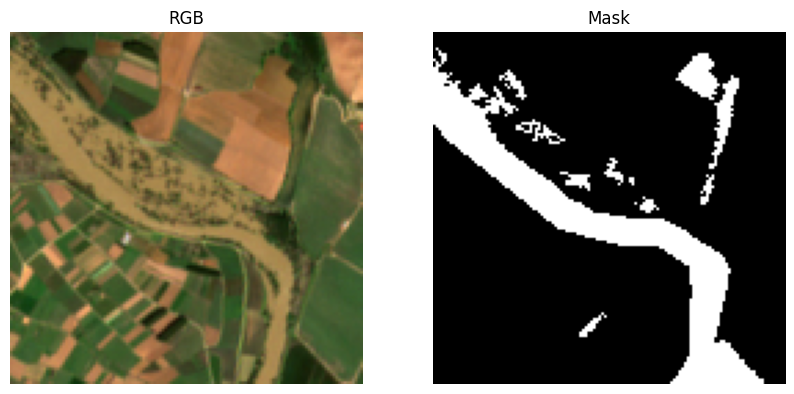

In [17]:
import matplotlib.pyplot as plt

rgb = np.load(
    train_rgb_paths[0]
)

mask = np.load(
    train_mask_paths[0]
)

rgb = np.transpose(
    rgb,
    (1,2,0)
)

plt.figure(
    figsize=(10,5)
)

plt.subplot(1,2,1)

plt.imshow(rgb)

plt.title("RGB")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    mask,
    cmap="gray"
)

plt.title("Mask")

plt.axis("off")

plt.show()

In [18]:
class HybridFloodDataset(Dataset):

    def __init__(
        self,
        rgb_paths,
        mask_paths,
        sam_paths
    ):

        self.rgb_paths = rgb_paths
        self.mask_paths = mask_paths
        self.sam_paths = sam_paths

    def __len__(self):

        return len(
            self.rgb_paths
        )

    def __getitem__(
        self,
        idx
    ):

        image = np.load(
            self.rgb_paths[idx]
        ).astype(np.float32)

        mask = np.load(
            self.mask_paths[idx]
        ).astype(np.float32)

        # Keep embeddings stored on disk as float16
        sam_feature = np.load(
            self.sam_paths[idx]
        )

        mask = np.expand_dims(
            mask,
            axis=0
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        # Convert to float32 for model compatibility
        sam_feature = torch.tensor(
            sam_feature,
            dtype=torch.float32
        )

        return (
            image,
            mask,
            sam_feature
        )

In [19]:
train_dataset = HybridFloodDataset(
    train_rgb_paths,
    train_mask_paths,
    train_sam_paths
)

val_dataset = HybridFloodDataset(
    val_rgb_paths,
    val_mask_paths,
    val_sam_paths
)

test_dataset = HybridFloodDataset(
    test_rgb_paths,
    test_mask_paths,
    test_sam_paths
)

In [20]:
image, mask, sam = train_dataset[0]

print("Image")

print(image.shape)
print(image.dtype)

print()

print("Mask")

print(mask.shape)
print(mask.dtype)

print()

print("SAM")

print(sam.shape)
print(sam.dtype)

Image
torch.Size([3, 128, 128])
torch.float32

Mask
torch.Size([1, 128, 128])
torch.float32

SAM
torch.Size([256, 64, 64])
torch.float32


In [21]:
print(
    image.min(),
    image.max()
)

print(
    torch.unique(mask)
)

print(
    sam.min(),
    sam.max()
)

tensor(0.) tensor(1.)
tensor([0., 1.])
tensor(-1.0410) tensor(0.8105)


In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [23]:
print(
    "Train:",
    len(train_loader)
)

print(
    "Validation:",
    len(val_loader)
)

print(
    "Test:",
    len(test_loader)
)

Train: 268
Validation: 34
Test: 34


In [24]:
images, masks, sams = next(
    iter(train_loader)
)

print(
    images.shape
)

print(
    masks.shape
)

print(
    sams.shape
)

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])
torch.Size([8, 256, 64, 64])


In [25]:
print(images.dtype)

print(masks.dtype)

print(sams.dtype)

torch.float32
torch.float32
torch.float32


In [26]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(
        self,
        x
    ):
        return self.block(x)

In [27]:
class EncoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(
            2
        )

    def forward(
        self,
        x
    ):

        features = self.conv(x)

        pooled = self.pool(
            features
        )

        return (
            features,
            pooled
        )

In [28]:
class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels +
            skip_channels,
            out_channels
        )

    def forward(
        self,
        x,
        skip
    ):

        x = self.up(x)

        x = torch.cat(
            [skip, x],
            dim=1
        )

        x = self.conv(x)

        return x

In [29]:
class HybridSAMUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.enc1 = EncoderBlock(
            3,
            64
        )

        self.enc2 = EncoderBlock(
            64,
            128
        )

        # SAM Reduction

        self.sam_reduce = nn.Conv2d(
            256,
            128,
            kernel_size=1
        )

        # Bottleneck

        self.bottleneck = DoubleConv(
            256,
            256
        )

        # Dropout

        self.dropout = nn.Dropout2d(
            p=DROPOUT_RATE
        )

        # Decoder

        self.dec2 = DecoderBlock(
            in_channels=256,
            skip_channels=128,
            out_channels=128
        )

        self.dec1 = DecoderBlock(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        # Output Layer

        self.final_conv = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(
        self,
        image,
        sam_feature
    ):

        # Encoder

        s1, p1 = self.enc1(
            image
        )

        s2, p2 = self.enc2(
            p1
        )

        # Resize SAM

        sam_feature = F.interpolate(
            sam_feature,
            size=(32, 32),
            mode="bilinear",
            align_corners=False
        )

        # Reduce SAM Channels

        sam_feature = self.sam_reduce(
            sam_feature
        )

        # Fusion

        fusion = torch.cat(
            [
                p2,
                sam_feature
            ],
            dim=1
        )

        # Bottleneck

        b = self.bottleneck(
            fusion
        )

        # Dropout

        b = self.dropout(
            b
        )

        # Decoder

        d2 = self.dec2(
            b,
            s2
        )

        d1 = self.dec1(
            d2,
            s1
        )

        # Output

        output = self.final_conv(
            d1
        )

        return output

In [30]:
model = HybridSAMUNet().to(device)

image = torch.randn(
    1,
    3,
    128,
    128
).to(device)

sam = torch.randn(
    1,
    256,
    64,
    64
).to(device)

with torch.no_grad():

    output = model(
        image,
        sam
    )

print(output.shape)

torch.Size([1, 1, 128, 128])


In [31]:
image = torch.randn(
    1,
    3,
    128,
    128
).to(device)

sam = torch.randn(
    1,
    256,
    64,
    64
).to(device)

with torch.no_grad():

    output = model(
        image,
        sam
    )

print(
    "Output Shape:",
    output.shape
)

Output Shape: torch.Size([1, 1, 128, 128])


In [32]:
images, masks, sams = next(
    iter(train_loader)
)

images = images.to(device)

sams = sams.to(device)

with torch.no_grad():

    outputs = model(
        images,
        sams
    )

print(
    outputs.shape
)

print(
    masks.shape
)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [33]:
model = HybridSAMUNet().to(device)

image = torch.randn(
    1,
    3,
    128,
    128
).to(device)

sam = torch.randn(
    1,
    256,
    64,
    64
).to(device)

with torch.no_grad():

    output = model(
        image,
        sam
    )

print(output.shape)

torch.Size([1, 1, 128, 128])


In [34]:
def iou_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)

    targets = targets.view(-1)

    intersection = (
        preds * targets
    ).sum()

    union = (
        preds.sum()
        + targets.sum()
        - intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.item()

In [35]:
def pixel_accuracy(
    preds,
    targets
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    correct = (
        preds == targets
    ).sum()

    total = targets.numel()

    return (
        correct.float()
        / total
    ).item()

In [36]:
def precision_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    tp = (
        preds * targets
    ).sum()

    fp = (
        preds *
        (1 - targets)
    ).sum()

    precision = (
        tp + smooth
    ) / (
        tp + fp + smooth
    )

    return precision.item()

In [37]:
CHECKPOINT_DIR = Path(
    "./checkpoints"
)

CHECKPOINT_DIR.mkdir(
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_hybrid_sam_unet.pth"
)

In [38]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": []
}

In [39]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks, sams in tqdm(loader):

        images = images.to(device)

        masks = masks.to(device)

        sams = sams.to(device)

        optimizer.zero_grad()

        outputs = model(
            images,
            sams
        )

        bce_loss = criterion(
            outputs,
            masks
        )

        l2_loss = 0.0

        for module in model.modules():

            if isinstance(
                module,
                nn.Conv2d
            ):

                l2_loss += (
                    module.weight ** 2
                ).sum()

        loss = (
            bce_loss
            +
            L2_LAMBDA * l2_loss
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

    num_batches = len(loader)

    return {

        "loss":
            running_loss / num_batches,

        "acc":
            running_acc / num_batches,

        "precision":
            running_precision / num_batches,

        "recall":
            running_recall / num_batches,

        "dice":
            running_dice / num_batches,

        "iou":
            running_iou / num_batches
    }

In [40]:
@torch.no_grad()

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks, sams in loader:

        images = images.to(device)

        masks = masks.to(device)

        sams = sams.to(device)

        outputs = model(
            images,
            sams
        )

        bce_loss = criterion(
            outputs,
            masks
        )

        l2_loss = 0.0

        for module in model.modules():

            if isinstance(
                module,
                nn.Conv2d
            ):

                l2_loss += (
                    module.weight ** 2
                ).sum()

        loss = (
            bce_loss
            +
            L2_LAMBDA * l2_loss
        )

        running_loss += loss.item()

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

    num_batches = len(loader)

    return {

        "loss":
            running_loss / num_batches,

        "acc":
            running_acc / num_batches,

        "precision":
            running_precision / num_batches,

        "recall":
            running_recall / num_batches,

        "dice":
            running_dice / num_batches,

        "iou":
            running_iou / num_batches
    }

In [41]:
NUM_EPOCHS = 1

In [42]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0
)

In [43]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [44]:
print(LEARNING_RATE)
print(L2_LAMBDA)
print(NUM_EPOCHS)

5e-05
1e-05
1


In [45]:
POS_WEIGHT = torch.tensor(
    [2.57],
    device=device
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=POS_WEIGHT
)

print(criterion)

BCEWithLogitsLoss()


In [46]:
def dice_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)

    targets = targets.view(-1)

    intersection = (
        preds * targets
    ).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        preds.sum()
        + targets.sum()
        + smooth
    )

    return dice.item()

In [47]:
def iou_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)

    targets = targets.view(-1)

    intersection = (
        preds * targets
    ).sum()

    union = (
        preds.sum()
        + targets.sum()
        - intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.item()

In [48]:
def pixel_accuracy(
    preds,
    targets
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    correct = (
        preds == targets
    ).sum()

    total = targets.numel()

    return (
        correct.float()
        / total
    ).item()

In [49]:
def precision_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    tp = (
        preds * targets
    ).sum()

    fp = (
        preds *
        (1 - targets)
    ).sum()

    precision = (
        tp + smooth
    ) / (
        tp + fp + smooth
    )

    return precision.item()

In [50]:
def recall_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    tp = (
        preds * targets
    ).sum()

    fn = (
        (1 - preds)
        * targets
    ).sum()

    recall = (
        tp + smooth
    ) / (
        tp + fn + smooth
    )

    return recall.item()

In [51]:
POS_WEIGHT = torch.tensor(
    [2.57],
    device=device
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=POS_WEIGHT
)

In [52]:
best_val_iou = 0.0

In [53]:
required_objects = [
    "model",
    "criterion",
    "optimizer",
    "scheduler",
    "train_loader",
    "val_loader",
    "history",
    "best_val_iou"
]

for obj in required_objects:
    print(obj, obj in globals())

model True
criterion True
optimizer True
scheduler True
train_loader True
val_loader True
history True
best_val_iou True


In [54]:
for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch "
        f"{epoch + 1}"
        f"/{NUM_EPOCHS}"
    )

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_acc"].append(
        train_metrics["acc"]
    )

    history["val_acc"].append(
        val_metrics["acc"]
    )

    history["train_precision"].append(
        train_metrics["precision"]
    )

    history["val_precision"].append(
        val_metrics["precision"]
    )

    history["train_recall"].append(
        train_metrics["recall"]
    )

    history["val_recall"].append(
        val_metrics["recall"]
    )

    history["train_dice"].append(
        train_metrics["dice"]
    )

    history["val_dice"].append(
        val_metrics["dice"]
    )

    history["train_iou"].append(
        train_metrics["iou"]
    )

    history["val_iou"].append(
        val_metrics["iou"]
    )

    print(
        f"Train Loss: {train_metrics['loss']:.4f}"
    )

    print(
        f"Val Loss: {val_metrics['loss']:.4f}"
    )

    print(
        f"Train IoU: {train_metrics['iou']:.4f}"
    )

    print(
        f"Val IoU: {val_metrics['iou']:.4f}"
    )

    if val_metrics["iou"] > best_val_iou:

        best_val_iou = (
            val_metrics["iou"]
        )

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "Best model saved."
        )


Epoch 1/1


  0%|          | 0/268 [00:00<?, ?it/s]

100%|██████████| 268/268 [01:39<00:00,  2.70it/s]


Train Loss: 0.7937
Val Loss: 0.6700
Train IoU: 0.4192
Val IoU: 0.4445
Best model saved.


In [55]:
NUM_EPOCHS = 150

In [56]:
best_val_iou = 0.0

for epoch in range(NUM_EPOCHS):

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_acc"].append(
        train_metrics["acc"]
    )

    history["val_acc"].append(
        val_metrics["acc"]
    )

    history["train_precision"].append(
        train_metrics["precision"]
    )

    history["val_precision"].append(
        val_metrics["precision"]
    )

    history["train_recall"].append(
        train_metrics["recall"]
    )

    history["val_recall"].append(
        val_metrics["recall"]
    )

    history["train_dice"].append(
        train_metrics["dice"]
    )

    history["val_dice"].append(
        val_metrics["dice"]
    )

    history["train_iou"].append(
        train_metrics["iou"]
    )

    history["val_iou"].append(
        val_metrics["iou"]
    )

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f}"
    )

    if val_metrics["iou"] > best_val_iou:

        best_val_iou = (
            val_metrics["iou"]
        )

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"Best Model Saved | "
            f"IoU: {best_val_iou:.4f}"
        )

100%|██████████| 268/268 [02:10<00:00,  2.06it/s]


Epoch [1/150] | Train Loss: 0.7404 | Val Loss: 0.6554 | Val IoU: 0.4506
Best Model Saved | IoU: 0.4506


100%|██████████| 268/268 [02:46<00:00,  1.61it/s]


Epoch [2/150] | Train Loss: 0.7198 | Val Loss: 0.6335 | Val IoU: 0.4582
Best Model Saved | IoU: 0.4582


100%|██████████| 268/268 [00:50<00:00,  5.26it/s]


...

Epoch [148/150] | Train Loss: 0.3363 | Val Loss: 0.4293 | Val IoU: 0.5862


100%|██████████| 268/268 [12:18<00:00,  2.76s/it]   


Epoch [149/150] | Train Loss: 0.3325 | Val Loss: 0.4278 | Val IoU: 0.5896


100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch [150/150] | Train Loss: 0.3359 | Val Loss: 0.4256 | Val IoU: 0.5897


In [57]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


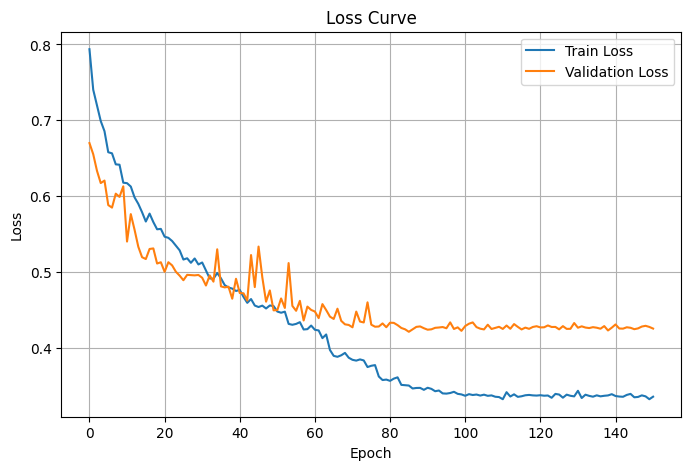

In [58]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

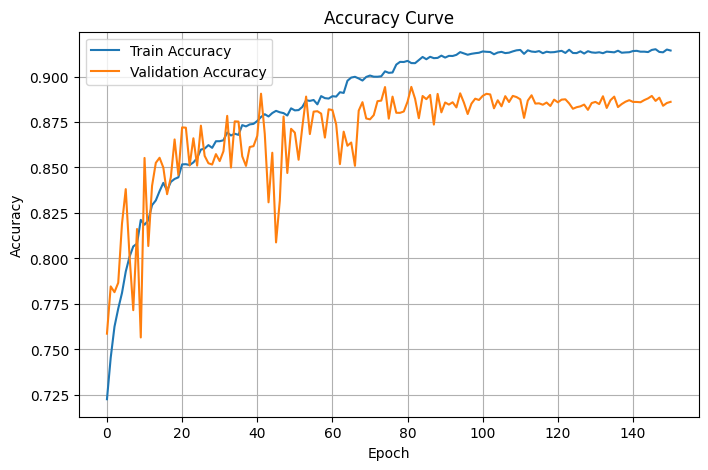

In [60]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.grid(True)

plt.show()

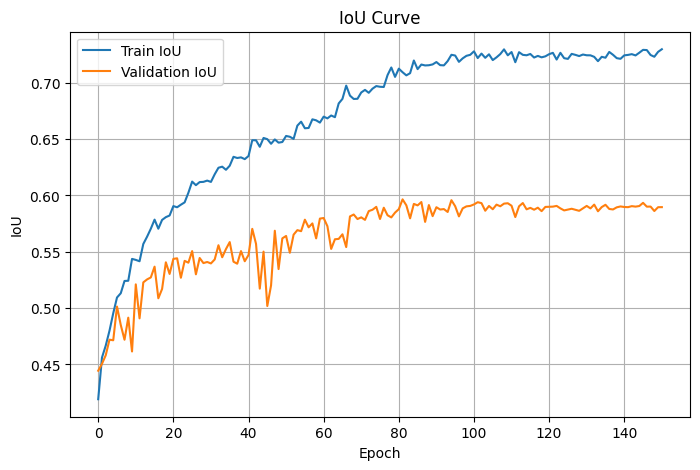

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")

plt.ylabel("IoU")

plt.title("IoU Curve")

plt.legend()

plt.grid(True)

plt.show()